<div style="text-align: center; font-weight: bold; font-size: 150%">Projet  - Manifold Learning</div><br>
<div style="text-align: center; font-size: 100%">Yayrale AKIBODE</div><br>
<div style="text-align: center; font-size: 100%">Professeur: Anis FRADI</div><br>
<div style="text-align: center; font-size: 100%">M2 MALIA - Université Lumière Lyon 2</div>


<div style="text-align: center; font-weight: bold; font-size: 125%">Résumé</div><br> 

Dans ce travail, nous nous sommes intéressés à l’apprentissage sur des espaces non linéaires, et plus particulièrement à la variété de Stiefel. L’objectif était de comprendre comment des formes peuvent évoluer et comment on peut passer d’un espace courbe à un cadre plus simple, en utilisant l’espace tangent et la géodésique associée. Une fois les données projetées dans cet espace linéaire, nous avons pu appliquer des techniques classiques comme la réduction de dimension, le clustering et la classification.

<div style="text-align: center; font-weight: bold; font-size: 125%">Introduction</div><br> 

Dans de nombreux domaines, notamment en mathématiques, il est souvent plus simple de travailler dans des espaces linéaires. Pourtant, certains problèmes sont fondamentalement non linéaires : on peut citer par exemple le traitement d’images, la reconnaissance faciale ou encore la robotique.
Dans ces cas, les méthodes classiques ne suffisent pas, car les données vivent sur des espaces courbes appelés variétés. C’est précisément là qu’intervient le manifold learning.

Ce projet s’inscrit dans ce contexte et s’intéresse à la déformation progressive d’un papillon vers une rosace. Dans un premier temps, nous visualiserons les formes. Nous les projeterons ensuite sur un espace tangent, où nous pourrons appliquer des méthodes classiques : réduction de dimension, clustering et classification.

<div style="text-align: center; font-weight: bold; font-size: 125%">Importation des packages</div><br> 

Avant de commencer le projet, nous commencerons par importer les packages qui nous seront nécessaires. Nous utiliserons principalement la librairie geomstats, qui est une librairie dédiée aux espaces courbes. 

In [297]:
#Chargement des packages
import scipy.io as io
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.patches import Ellipse

import warnings
warnings.filterwarnings("ignore")

import geomstats
print("Geomstats version :", geomstats.__version__)
import geomstats._backend as gs
gs.numpy.set_default_dtype("float64")
from geomstats.geometry.stiefel import Stiefel
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.pca import TangentPCA

from sklearn import manifold
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, f1_score, confusion_matrix

from scipy.stats import gaussian_kde
from scipy.optimize import linear_sum_assignment

Geomstats version : 2.8.0


<div style="text-align: center; font-weight: bold; font-size: 125%">Chargement des données</div><br> 

Nous allons travailler avec un dataset '.mat' qui est un fichier Matlab. Le fichier téléchargé est un dictionnaire. Lorsque nous affichons ses clés, nous pouvons remarquer qu'il contient une variable $Q$ qui est un tableau. En effet, c'est le dataset avec lequel nous allons travailler. Nous allons analyser Q afin de nous familiariser avec les jeux de données.

$Q$ est un tableau de type numpy qui comprend 51 éléments. Chaque élément de $Q$ est lui-même un tableau de taille (100, 2).

En effet, $Q$ sauvegarde à travers le temps la transformation continue d'une forme de référence à une autre. Les formes intermédiares correspondant chacune à un instant t (t $\in [0, 1]$) ont été obtenues en échantillonnant de manière uniforme le chemin géodésique reliant les deux formes de référence.

In [298]:
#Chargement des données
dataset = io.loadmat('data/Shapes_Gr.mat')

#Variables du dataset
print("Variables du dataset : ", dataset.keys())

#Extraction et redimensionnement de Q
Q = dataset['Q']
Q = Q.reshape(-1, 1)
Q = Q.flatten()

#Initialisation de la variété Stiefel
d, p = Q[0].shape
st = Stiefel(d, p)

#Type & Shape de Q
print("Q est de type : ", type(Q))
print("Q est de dimension : ", Q.shape)

#Type & Shape d'un élément de  Q
print("Q[0] est de type : ", type(Q[0]))
print("Q[0] est de dimension : ", Q[0].shape)

Variables du dataset :  dict_keys(['__header__', '__version__', '__globals__', 'Q'])
Q est de type :  <class 'numpy.ndarray'>
Q est de dimension :  (51,)
Q[0] est de type :  <class 'numpy.ndarray'>
Q[0] est de dimension :  (100, 2)


<div style="text-align: center; font-weight: bold; font-size: 125%">Visualisation des données</div><br> 

La première forme et la dernière forme de $Q$ sont les deux formes de référence. La déformation progressive est très bien visualisée avec le graphe ci-dessous. Nous passons d'une forme de papillon à une forme de rosace.

Si nous comparons les deux graphes, nous voyons bien que le chemin géodésique retrace bien la déformation progressive des formes de référence. Cela nous permettra de générer plus de formes.

Dans la suite, nous allons travailler avec un nouveau Q de taille 201. Cela sera utile lorsque nous allons passer au clustering.

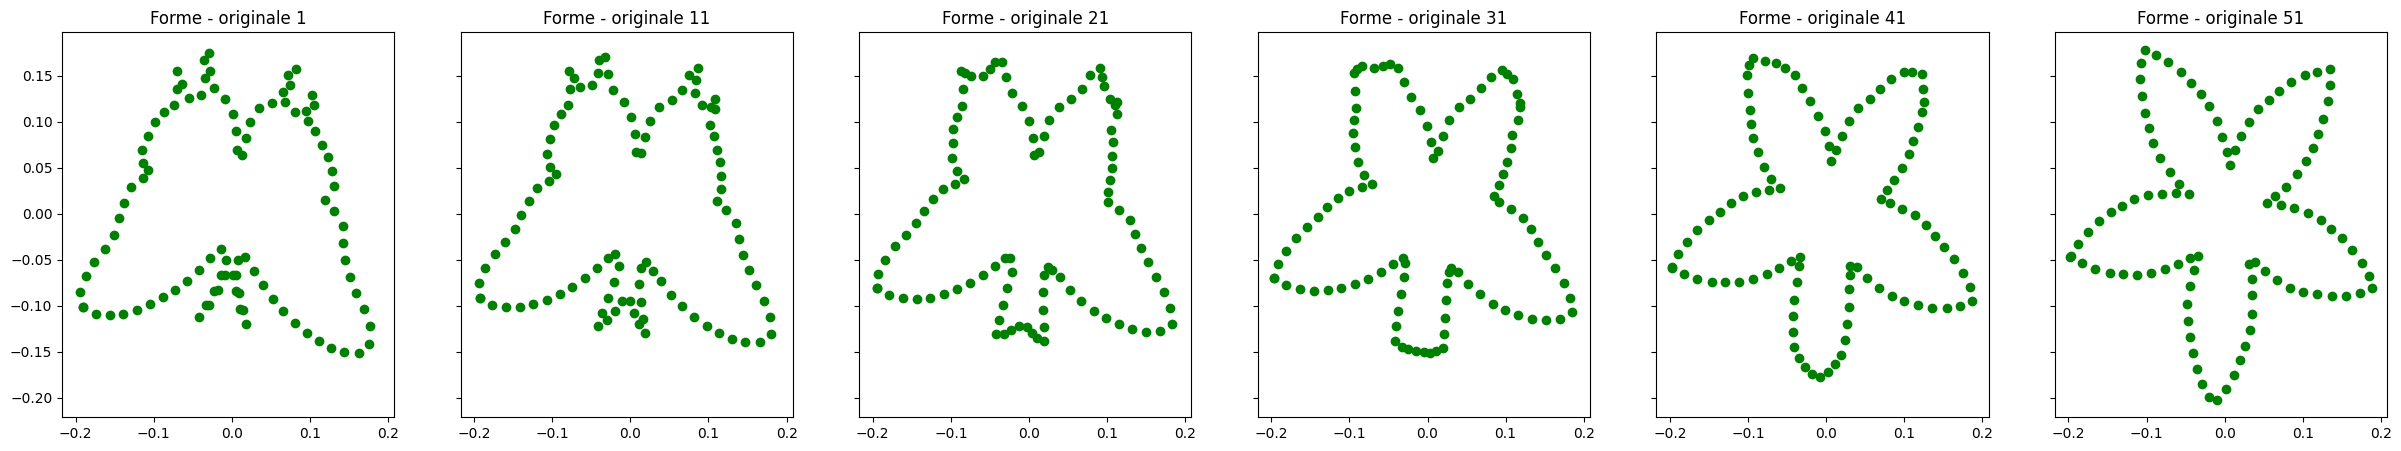

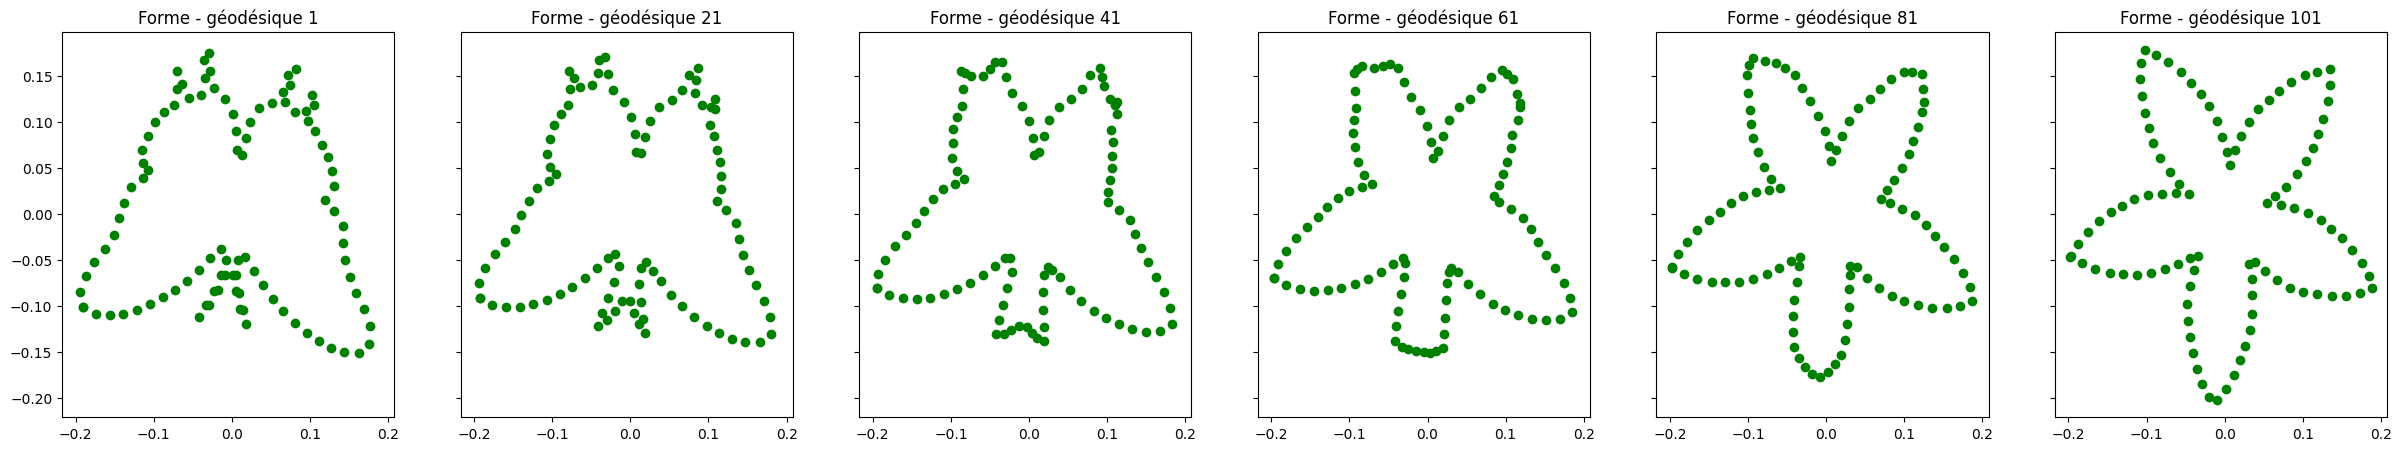

In [299]:
#Sélection aléatoire uniforme de quelques formes
indexes = range(0, len(Q), 10)

#Visualisation des formes à travers le temps
fig, axes = plt.subplots(1, 6, figsize = (30, 5), sharex=True, sharey=True)
for i,index in enumerate(indexes): 
    axes[i].scatter(Q[index][:,0], Q[index][:,1], color='green')
    axes[i].set_title("Forme - originale " + str(index+1))
plt.show()

#Visualisation du chemin géodésique
geodesic = st.metric.geodesic(initial_point=Q[0], end_point=Q[-1]) #Création de la géodésique entre la première et la dernière forme
time = np.linspace(0, 1, num=101)
path = geodesic(time)
geodesic_indexes = range(0, len(path), 20)
fig, axes = plt.subplots(1, 6, figsize = (30, 5), sharex=True, sharey=True)
axes = axes.flatten()
for i,index in enumerate(geodesic_indexes): 
    axes[i].scatter(path[index][:,0], path[index][:,1], color='green')
    axes[i].set_title("Forme - géodésique " + str(index+1))
plt.show()

#Génération d'un autre dataset Q avec n_samples = 201
time = np.linspace(0, 1, num=201)
Q = geodesic(time)

<div style="text-align: center; font-weight: bold; font-size: 125%">1. Vérification de la structure des données </div><br> 

Chaque forme est une matrice appartenant à $St(p, d) = \{A \in \mathbb{R}^{d\times p} ∣ A^TA = I_p\}$ (espace de Stiefel). Dans un premier temps nous vérifierons si cela est vrai et dans un deuxième temps, nous discuterons la non linéarité de cet espace.

D'après les résultats suivants il est évident que $St(p, d)$ n'est pas linéaire.

In [281]:
#Vérifions que toutes les formes appartiennent à St
all_in_st = 0
for i, forme in enumerate(Q): 
    if not st.belongs(forme):
        print("Forme", i+1, "not in St")
        all_in_st = 1
if all_in_st == 0:
    print("All forms in St.")

#Vérifions que St n'est pas linéaire
a=2
b=3
linear_combination  = a*Q[0] + a*Q[1] #combinaison de deux éléments de St.
print("Linear combination in St : ", st.belongs(linear_combination)) #False si St n'est pas linéaire.

All forms in St.
Linear combination in St :  False


<div style="text-align: center; font-weight: bold; font-size: 125%">2. Calcul et visualisation de la moyenne de Fréchet</div><br> 

Nous allons maintenant calculer la moyenne de Fréchet des données. Nous la visualiserons également. 

Nous pouvons remarquer que la moyenne a une forme intermédiaire entre les deux formes de référence.

New shape of Q :  (201, 100, 2)
Mean shape belongs to St :  True


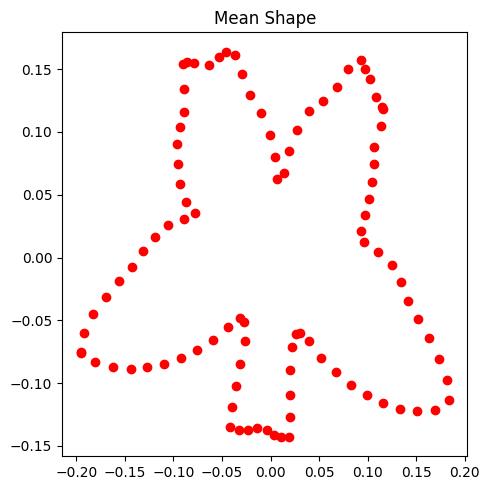

In [282]:
#Redimensionnement de Q
Q = np.stack(Q, axis=0)
print("New shape of Q : ", Q.shape)

#Calcul de la moyenne de Fréchet
mean_estimator = FrechetMean(space = st)
mean_estimator.fit(Q)
mean = mean_estimator.estimate_
print("Mean shape belongs to St : ", st.belongs(mean))

#Visualisation de la moyenne
plt.figure(figsize=(5, 5))
plt.scatter(mean[:,0], mean[:,1], color='red')
plt.title("Mean Shape")
plt.tight_layout()
plt.show()

<div style="text-align: center; font-weight: bold; font-size: 125%">3. Vérification des outils géométriques</div><br> 

Après consultation de la documentation [(ici)](https://geomstats.github.io/api/geomstats.geometry.html#geomstats.geometry.stiefel.Stiefel) de la variété Stiefel, les outils géométriques nécessaires sont bien définis. Nous allons donc les exploiter afin de déterminer le chemin géodésique maximal entre deux formes.

In [283]:
#Calcul du chemin géodésique maximal entre deux formes
geodesic_distances = np.zeros((len(Q), len(Q)))
for i in range(len(Q)-1):
    for j in range(i+1, len(Q)):
        distance = st.metric.dist(point_a=Q[i], point_b=Q[j])
        geodesic_distances[i, j] = distance 
max_distance = np.max(geodesic_distances) #Distance géodésique maximale
max_indices = np.unravel_index(np.argmax(geodesic_distances), geodesic_distances.shape)
print("Maximal geodesic distance ", max_distance, "is between shape ", max_indices[0]+1, " and shape ", max_indices[1]+1, ".")

Maximal geodesic distance  0.4891934907945981 is between shape  1  and shape  201 .


<div style="text-align: center; font-weight: bold; font-size: 125%">4. Projection sur l’espace tangent</div><br> 

Dans cette section, nous projetterons les données sur l'espace tangent en prenant comme point de base la moyenne de Fréchet.

Discussion contraintes des vecteurs tangents: la propriété d'antisymétrie.

La contrainte de définition des matrices de Stiefel peut s'écrire comme une fonction
$$
F(X) = X^\top X - I_p = 0.
$$

Considérons une courbe $X(t)$ dans $\mathrm{St}(p,d)$ telle que
$$
X(0) = X
\quad\text{et}\quad
\dot X(0) = Z,
$$

où $Z$ représente un vecteur tangent à la variété en $X$.

Comme $X(t)$ reste sur la variété pour tout $t$, on a
$$
F(X(t)) = X(t)^\top X(t) - I_p = 0
\quad\text{pour tout } t.
$$

Dérivons F par rapport à t: 

$$
\frac{d}{dt}\Big(X(t)^\top X(t)\Big)
= \dot X(t)^\top X(t) + X(t)^\top \dot X(t).
$$

En évaluant en $t=0$ :

$$
0 = \frac{d}{dt}\Big|_{t=0} (X(t)^\top X(t))
   = Z^\top X + X^\top Z.
$$

On obtient donc: 

$$
X^\top Z + Z^\top X = 0.
$$


La condition précédente signifie que la matrice $X^\top Z$ est antisymétrique.

Ainsi, l'espace tangent en $X$ à la variété de Stiefel est donné par:

$$
T_X \mathrm{St}(p,n)
=
\{ Z \in \mathbb{R}^{n \times p} \;|\; X^\top Z + Z^\top X = 0 \}.
$$

Shape of tangent vectors :  (201, 100, 2)
All tangent vectors are antisymmetric.


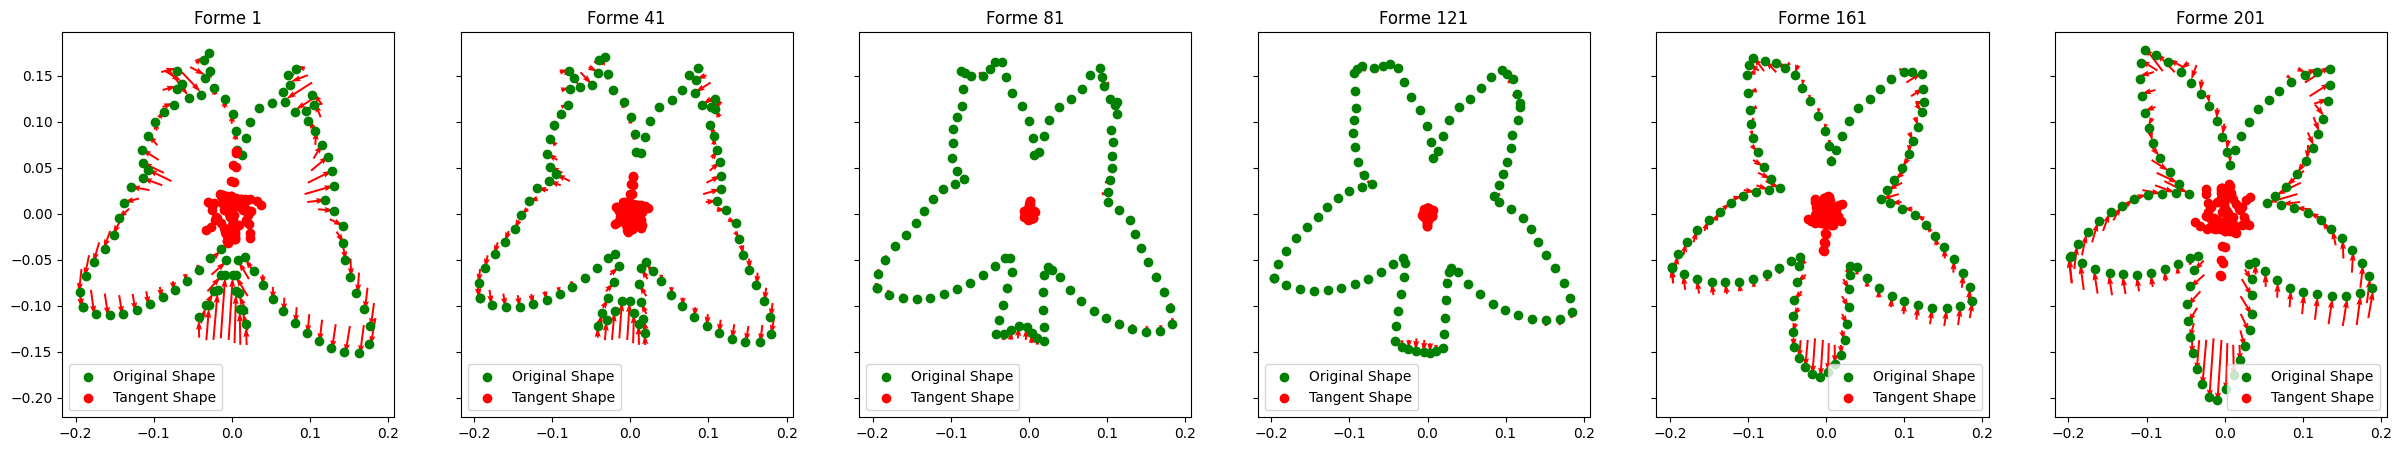

In [284]:
#Projection sur l’espace tangent en la moyenne
tangent_vectors = st.to_tangent(Q, mean)
print("Shape of tangent vectors : ", tangent_vectors.shape)

#Vérification de la contrainte d'antisymétrie des vecteurs tangents
term1 = np.einsum('ij,njk->nik', mean.T, tangent_vectors)
term2 = np.einsum('nij,jk->nik', tangent_vectors.transpose(0, 2, 1), mean)
norm = np.linalg.norm(term1 + term2)
if norm< 1e-6:
    print("All tangent vectors are antisymmetric.")
else:
    print("Some tangent vectors are not antisymmetric.")

#Visualisation de quelques vecteurs tangents
indexes = range(0, len(Q), 40)
fig, axes = plt.subplots(1, 6, figsize = (30, 5), sharex=True, sharey=True)
for i,index in enumerate(indexes): 
    axes[i].quiver(mean[:,0], mean[:,1], tangent_vectors[index][:,0], tangent_vectors[index][:,1], color='red', angles='xy', scale_units='xy', scale=1)
    axes[i].scatter(Q[index][:,0], Q[index][:,1], color='green', label='Original Shape')
    axes[i].scatter(tangent_vectors[index][:,0], tangent_vectors[index][:,1], color='red', label='Tangent Shape')
    axes[i].set_title("Forme " + str(index+1))
    axes[i].legend()
plt.show()

<div style="text-align: center; font-weight: bold; font-size: 125%">5. Réduction de dimension</div><br> 

Pour la réduction de dimension, nous allons tester les techniques linéaires et les techniques non linéaires. Les techniques classiques s'appliquent sur des tableaux de données 2D. Pour cela, nous allons appliquer ces techniques sur un tableau de distances. Le tableau de distances comprend les distances entres les vecteurs tangents.

Les techniques que nous testerons sont listés ci-dessous: 

- TangentPCA: c'est l'ACP générique du package geomstats. Elle est directement appliquée sur les vecteurs tangents.
- ACP classique: appliquée sur la matrice de distances.
- ACP à noyau gaussien: appliquée sur la matrice de distances.
- ACP à noyau polynomial: appliquée sur la matrice de distances.
- Isomap: appliquée sur la matrice de distances.
- Locally Linear Embedding (LLE): appliquée sur la matrice de distances.
- t-SNE: appliquée sur la matrice de distances.

In [285]:
#Réduction de dimension
n_components = 2
random_state = 0

#Normalisation des données
scaler = StandardScaler()
X_reshaped = tangent_vectors.reshape(-1, tangent_vectors.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
tangent_vectors = X_scaled.reshape(tangent_vectors.shape)

#Calcul des distances géodésiques entre les vecteurs tangents
tangent_dist = np.zeros((len(Q), len(Q)))
for i in range(len(Q)-1):
    for j in range(i+1, len(Q)):
        distance = st.metric.norm(tangent_vectors[i] - tangent_vectors[j], base_point=mean) #Norme des différences des vecteurs tangents
        tangent_dist[i, j] = distance 

#TangentPCA
tangentpca_Q = TangentPCA(space=st, n_components=n_components, random_state=random_state).fit_transform(tangent_vectors, base_point=mean)

#PCA
pca_Q = PCA(n_components=n_components, random_state=random_state).fit_transform(tangent_dist)

#Isomap
isompa_Q = manifold.Isomap(n_components=n_components).fit_transform(tangent_dist)

#LLE
lle_Q = manifold.LocallyLinearEmbedding(n_components=n_components).fit_transform(tangent_dist)

#T-SNE
tsne_Q = manifold.TSNE(n_components=n_components, random_state=random_state, perplexity=12).fit_transform(tangent_dist)


L'ACP à noyau demande un choix d'hyperparamètres, donc nous allons faire des réductions de dimension avec plusieurs valeurs et déterminer l'hyperparamètre qui nous donne la meilleure réduction de dimension. Pour cela nous allons analyser la variance expliquée.

In [286]:
#ACP à noyau

#KernelPCA avec noyau RBF
var_rbf_gaussien  = [0.1, 1, 5, 10]
for i, var in enumerate(var_rbf_gaussien):
    kpca_rbf_Q = KernelPCA(n_components=2, kernel='rbf', gamma=var, fit_inverse_transform=True, random_state=0).fit_transform(tangent_dist)
    variance = kpca_rbf_Q.var(axis=0)
    print(f"Variance explained by components with RBF kernel (gamma={var}): {variance}")

#PolyPCA
p_degree  = [2, 3, 4, 5]
for i, p in enumerate(p_degree):
    try: 
        kpca_poly_Q = KernelPCA(n_components=2, kernel='poly', degree=p, gamma=1, coef0=1, fit_inverse_transform=True, random_state=0).fit_transform(tangent_dist)
    except Exception as e:
        print(f"Error with degree {p}: {e}")
        continue
    variance = kpca_poly_Q.var(axis=0)
    print(f"Variance explained by components with Polynomial kernel (degree={p}): {variance}")

Variance explained by components with RBF kernel (gamma=0.1): [0.03801887 0.02584435]
Variance explained by components with RBF kernel (gamma=1): [0.01797388 0.01209829]
Variance explained by components with RBF kernel (gamma=5): [0.0104729  0.00710523]
Variance explained by components with RBF kernel (gamma=10): [0.00827271 0.00579856]
Error with degree 2: Matrix is singular.
Error with degree 3: Matrix is singular.
Error with degree 4: Matrix is singular.
Error with degree 5: Matrix is singular.


En analysant la variance expliquée, le meilleur hyperparamètre pour l'ACP à noyau gaussien est $var=0.1$. En ce qui concerne l'ACP à noyau polynomial, elle génère des erreurs pour toute les valeurs dues à la singularité des matrices donc nous allons la retirer de la liste des techniques.

In [287]:
#KernelPCA avec noyau RBF
kpca_rbf_Q = KernelPCA(n_components=2, kernel='rbf', gamma=0.1, fit_inverse_transform=True, random_state=0).fit_transform(tangent_dist) #var = 0.1

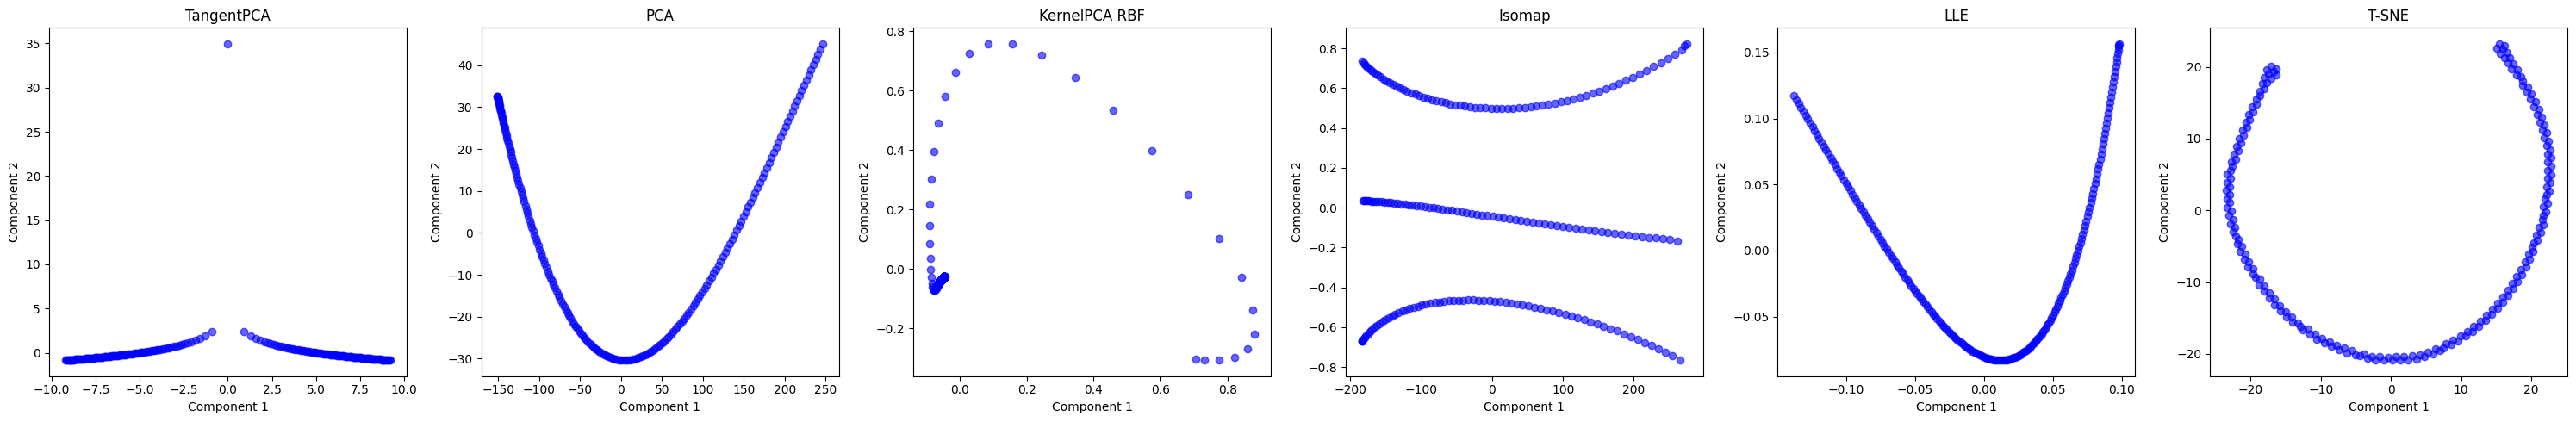

In [288]:
#Visualisation finale des réductions de dimension
methods = {
    'TangentPCA': tangentpca_Q,
    'PCA': pca_Q,
    'KernelPCA RBF': kpca_rbf_Q,
    'Isomap': isompa_Q,
    'LLE': lle_Q,
    'T-SNE': tsne_Q
}
fig, axes = plt.subplots(1, len(methods), figsize=(len(methods)*5, 5))
axes = axes.flatten()
for i, (method_name, embedding) in enumerate(methods.items()):
    axes[i].scatter(embedding[:, 0], embedding[:, 1], c='blue', alpha=0.6)
    axes[i].set_xlabel('Component 1')
    axes[i].set_ylabel('Component 2')
    axes[i].set_title(method_name)
plt.tight_layout()
plt.show()

<div style="text-align: center; font-weight: bold; font-size: 125%">6. Statistiques descriptives</div><br> 

Après avoir projeté les données, nous étudierons leur distribution. Ces analyses vont nous donner des informations sur les prochains résultats.

La distribution du TangentPCA représente très bien deux clusters bien séparés. Cette méthode donnera probablement de très bon résultats lors du clustering. Les autres distributions sont assez atypiques et ne nous donnent pas une grande information.

Mean of TangentPCA embedding: [-2.73965483e-16 -7.67766171e-17]
Mean of PCA embedding: [0.00000000e+00 2.82803079e-15]
Mean of KernelPCA RBF embedding: [4.41879811e-18 6.62819716e-18]
Mean of Isomap embedding: [1.80993971e-14 1.06759101e-12]
Mean of LLE embedding: [-4.66794621e-09 -1.53108413e-12]
Mean of T-SNE embedding: [ 0.23541743 -1.9275563 ]
Variance of TangentPCA embedding: [42.73536705  6.53925785]
Variance of PCA embedding: [15426.82747244   526.11744481]
Variance of KernelPCA RBF embedding: [0.03801887 0.02584435]
Variance of Isomap embedding: [1.92045037e+04 2.33367710e-01]
Variance of LLE embedding: [0.00497512 0.00497512]
Variance of T-SNE embedding: [311.06027 197.38034]


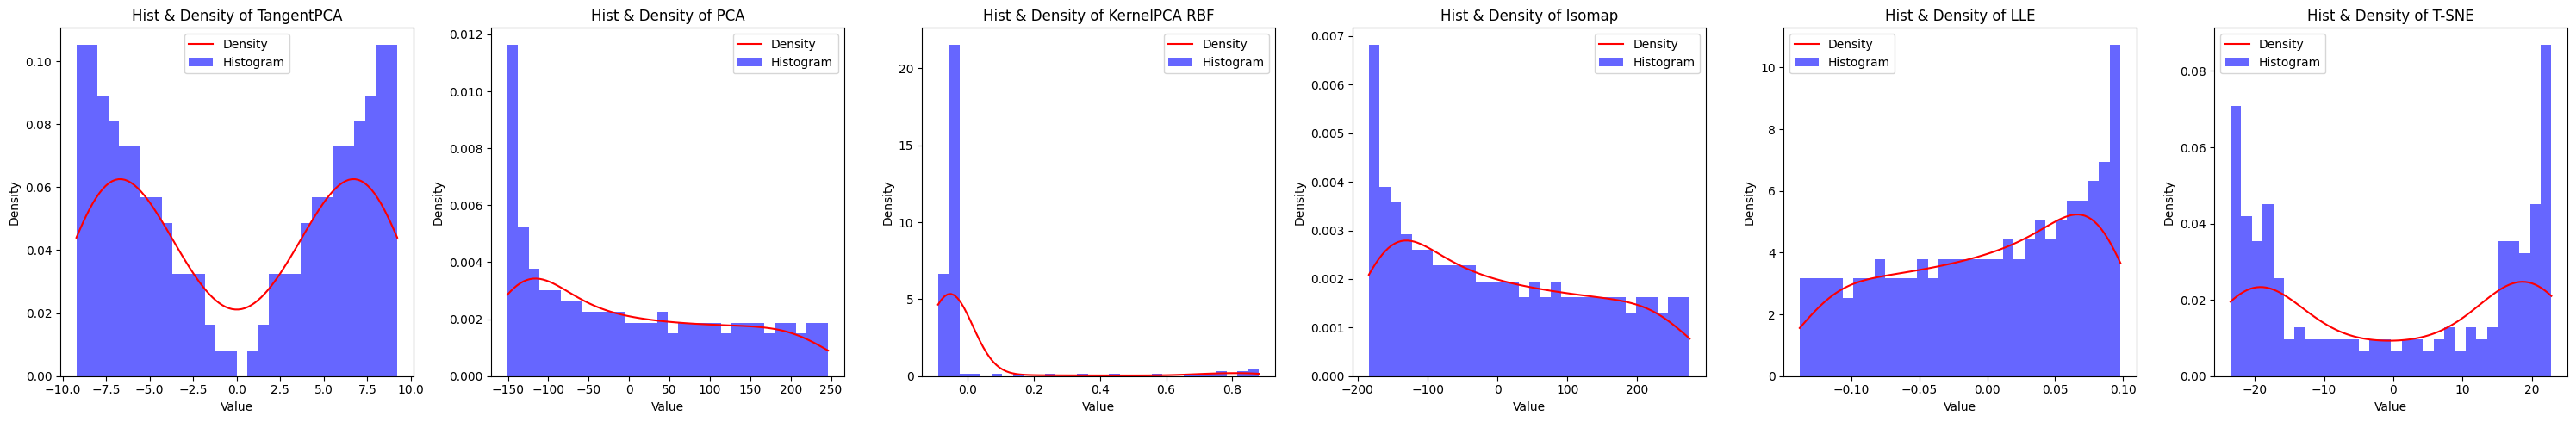

In [289]:
#Moyenne des embeddings
for method_name, embedding in methods.items():
    mean_embedding = np.mean(embedding, axis=0)
    print(f"Mean of {method_name} embedding: {mean_embedding}")

#Variance des embeddings
for method_name, embedding in methods.items():
    variance_embedding = np.var(embedding, axis=0)
    print(f"Variance of {method_name} embedding: {variance_embedding}")

#Visualisation de l'histogramme et de la densité de probabilité des premières composantes
fig, axes = plt.subplots(1, len(methods), figsize=(len(methods)*5, 5))
axes = axes.flatten()
for i, (method_name, embedding) in enumerate(methods.items()):
    kde = gaussian_kde(embedding[:, 0])
    x_range = np.linspace(np.min(embedding[:, 0]), np.max(embedding[:, 0]), 100)
    axes[i].plot(x_range, kde(x_range), color='r', label='Density')
    axes[i].hist(embedding[:, 0], bins=30, density=True, alpha=0.6, color='b', label='Histogram')
    axes[i].set_title(f'Hist & Density of {method_name}')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

<div style="text-align: center; font-weight: bold; font-size: 125%">7. Clustering des données projetées</div><br> 

Cette section va couvrir le clustering des données réduites. Pour cela, nous testerons deux méthodes de clustering qui sont le GMM et le KMeans.

Graphiquement, la combinaison du KMeans sur les données réduites par la technique de TangentPCA donne une très bonne séparation des deux clusters(cela était déjà envisageable dans la section précédente). Dans la suite, nous travaillerons avec les résultats  de cette combinaison. 

Toutefois les techniques PCA et Isomap ont également donné de très bons résultats. Les autres techniques présentent une très forte asymétrie dans la prédiction des clusters.

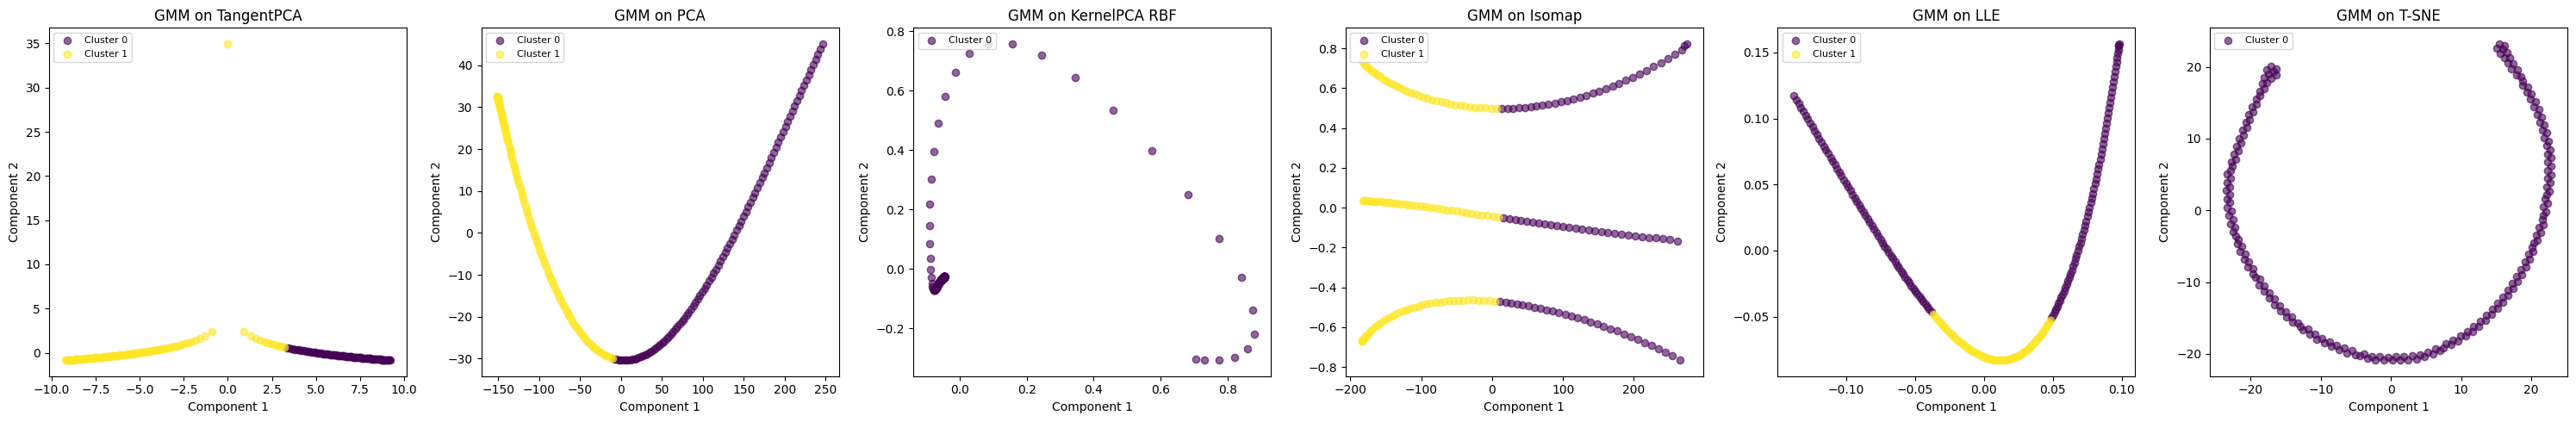

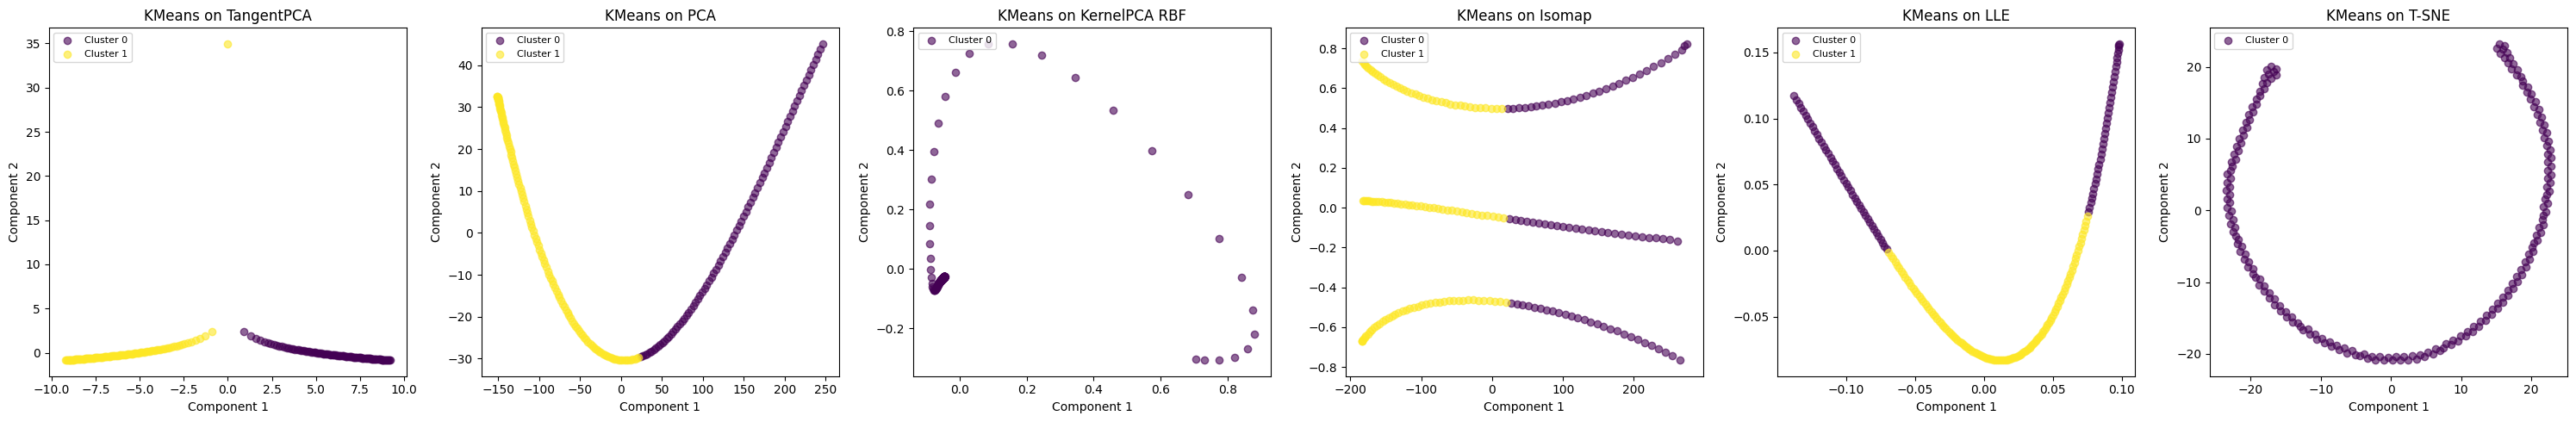

In [290]:
K=2

#Arrangement des labels pour une meilleure visualisation
def relabel(labels):
    relabeled = np.zeros_like(labels)
    if labels[0]== 0:
        return relabeled
    else: 
        relabeled[labels == 1] = 0
        relabeled[labels == 0] = 1
        return relabeled
    
gmm_labels = {
    'TangentPCA': None,
    'PCA': None,
    'KernelPCA RBF': None,
    'Isomap': None,
    'LLE': None,
    'T-SNE': None,
}

kmeans_labels = {
    'TangentPCA': None,
    'PCA': None,
    'KernelPCA RBF': None,
    'Isomap': None,
    'LLE': None,
    'T-SNE': None,
}

#GMM
fig, axes = plt.subplots(1, len(methods), figsize=(len(methods)*5, 5))
axes = axes.flatten()
cmap = plt.cm.get_cmap("viridis", K)
gmm = GaussianMixture(n_components=K, random_state=random_state)
for i, (method_name, embedding) in enumerate(methods.items()):
    gmm.fit(embedding)
    labels = relabel(gmm.predict(embedding))
    gmm_labels[method_name] = labels
    for j, k in enumerate(np.unique(labels)):
        idx = labels == k
        axes[i].scatter(embedding[idx, 0], embedding[idx, 1], color=cmap(j), alpha=0.6, label=f"Cluster {k}")
        axes[i].set_title(f'GMM on {method_name}')
        axes[i].set_xlabel('Component 1')
        axes[i].set_ylabel('Component 2')
        axes[i].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

#Kmeans
fig, axes = plt.subplots(1, len(methods), figsize=(len(methods)*5, 5))
axes = axes.flatten()
kmeans = KMeans(n_clusters=K, random_state=random_state)
for i, (method_name, embedding) in enumerate(methods.items()):
    kmeans.fit(embedding)
    labels = relabel(kmeans.labels_)
    kmeans_labels[method_name] = labels
    for j, k in enumerate(np.unique(labels)):
        idx = labels == k
        axes[i].scatter(embedding[idx, 0], embedding[idx, 1], color=cmap(j), alpha=0.6, label=f"Cluster {k}")
        axes[i].set_title(f'KMeans on {method_name}')
        axes[i].set_xlabel('Component 1')
        axes[i].set_ylabel('Component 2')
        axes[i].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Après avoir choisi la meilleur combinaison, nous allons visualiser ses différentes propriétés en faisant une visualisation par ellipses.

L'ellipse du cluster 1 est très rallongée donc la variance de ce cluster est très grande. D'autre part, les poids sont de 0.5 pour chaque cluster. Cela veut dire que les formes ont été uniformément séparées en deux classe. Ce qui épouse parfaitement le contexte du problème.

Weights of each cluster: [0.49751244 0.50248756]


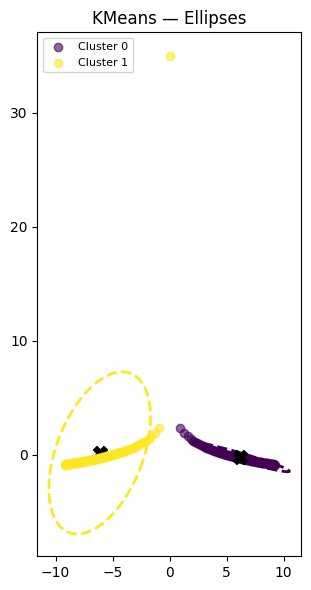

In [291]:
#Visualisation des clusters, centroïdes, covariances, poids
def plot_covariance_ellipse(mean, cov, axe, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    axe.add_patch(ellipse)

fig, axe = plt.subplots(1, 1, figsize=(7, 6))
cmap = plt.cm.get_cmap("viridis", K)
n_std = 2.0

kmeans = KMeans(n_clusters=K, random_state=random_state)
kmeans.fit(methods['TangentPCA'])
labels = relabel(kmeans.labels_)
means = kmeans.cluster_centers_
covs = []
for j, k in enumerate(np.unique(labels)):
    idx = labels == k
    Xk = methods['TangentPCA'][idx]
    axe.scatter(Xk[:, 0], Xk[:, 1], color=cmap(j),alpha=0.6, label=f"Cluster {k}")

    # Centroïde
    axe.scatter(means[k, 0], means[k, 1], color="black", marker="X", s=100)

    # Covariance empirique (approximation)
    if len(Xk) > 2:
        cov = np.cov(Xk.T)
        plot_covariance_ellipse(means[1-j], cov, axe, n_std=n_std, edgecolor=cmap(j), facecolor="none", linestyle="--", linewidth=2)


weights = np.bincount(labels) / len(labels)
print("Weights of each cluster:", weights)

axe.set_title("KMeans — Ellipses")
axe.set_aspect("equal")
axe.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

<div style="text-align: center; font-weight: bold; font-size: 125%">8. Visualisation des formes originales selon les clusters</div><br> 

Les visualisations faites résultent de la combinaison entre le TangentPCA et le KMeans. Les premières formes sont classées comme papillon et les dernières comme la rosace.

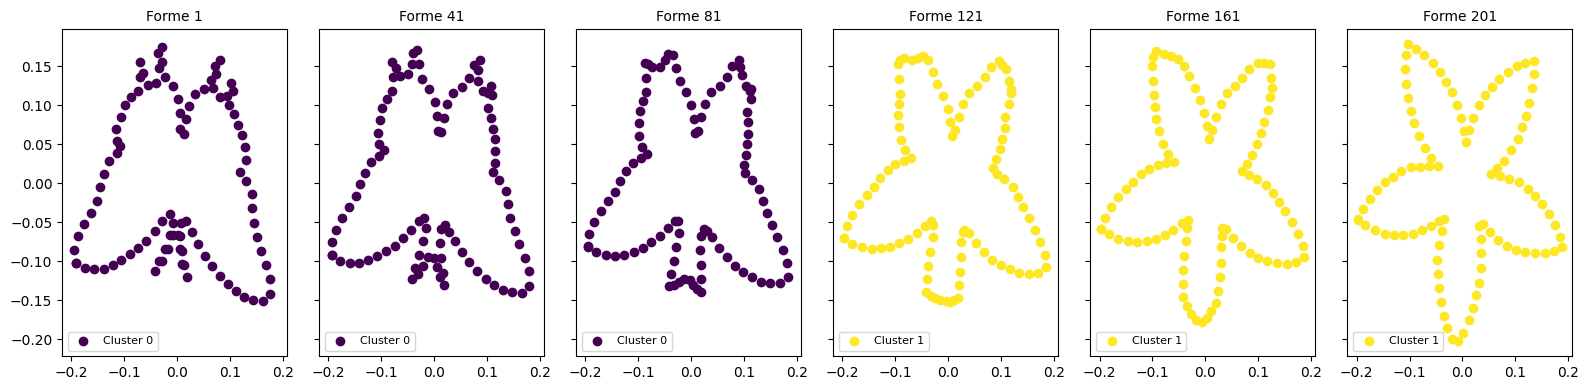

In [292]:
#Visualisation des formes originales
indexes = range(0, len(Q), 40)
fig, axes = plt.subplots(1, 6, figsize = (16, 4), sharex=True, sharey=True)
axes = axes.flatten()
labels = kmeans_labels['TangentPCA']
for i,index in enumerate(indexes): 
    axes[i].scatter(Q[index][:,0], Q[index][:,1], color=cmap(labels[index]), label=f"Cluster {labels[index]}")
    axes[i].set_title(f"Forme {str(index+1)}", fontsize=10)
    axes[i].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

<div style="text-align: center; font-weight: bold; font-size: 125%">9.Classification supervisée </div><br> 

Nous allons maintenant utiliser les labels trouvés afin de faire une classification. Pour cela nous allons apprendre deux modèles.

Les deux modèles sont: 
- La régression logistique
- Les SVM

In [293]:
#Classification des données
X= methods['TangentPCA']
y = kmeans_labels['TangentPCA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=random_state) #Echantillonnage stratifié

#Régression logistique
logreg = LogisticRegression(random_state=random_state)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

#SVM
svm = SVC(random_state=random_state)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

<div style="text-align: center; font-weight: bold; font-size: 125%">10.Évaluation du modèle </div><br> 

Afin d'évaluer les performances des modèles, nous allons analyser les métriques suivants: 
- Accuracy
- AUC
- F1 - score
- Matrice de confusion
- Courbe ROC

La diversification des métriques ne nous apportent pas une très grande information. Ils disent tous la même chose. Les classifieurs sont arrivés à prédire les bonnes classes.

Il est par contre très intéressant de discuter les matrices de confusion. En effet, nous avons 201 formes. Le clustering a réparti les données en deux classes uniformes. Il reste donc une forme dont la prédiction est mitigée. Les SVM l'ont prédite comme une forme 1, tandis que la régression logistique l'a prédite comme une forme 0. En effet, le clustering l'a classé comme une forme 1.

Accuracy of Logistic Regression: 0.99
Accuracy of SVM: 1.00
AUC of Logistic Regression: 1.00
AUC of SVM: 1.00
F1-Score of Logistic Regression: 0.99
F1-Score of SVM: 1.00


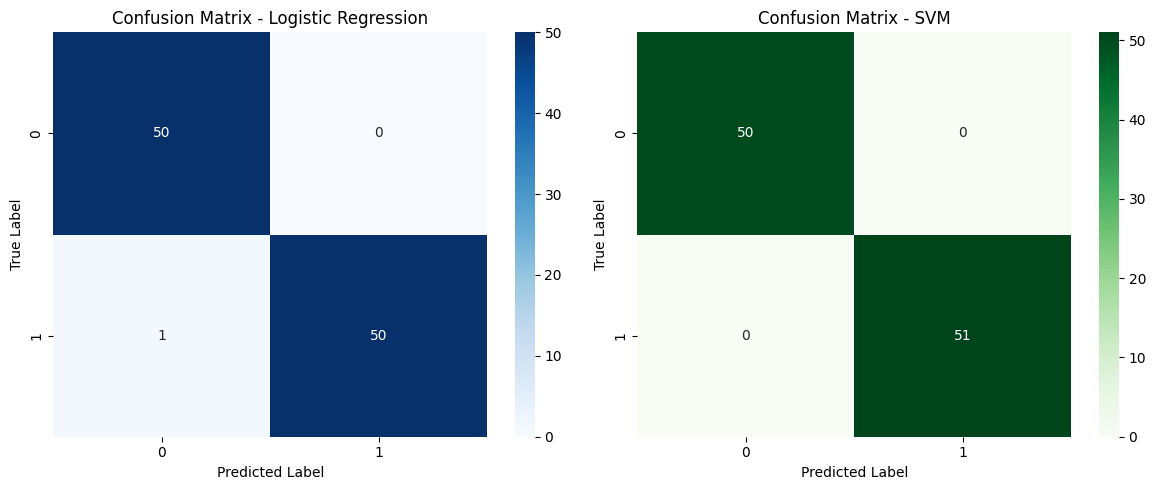

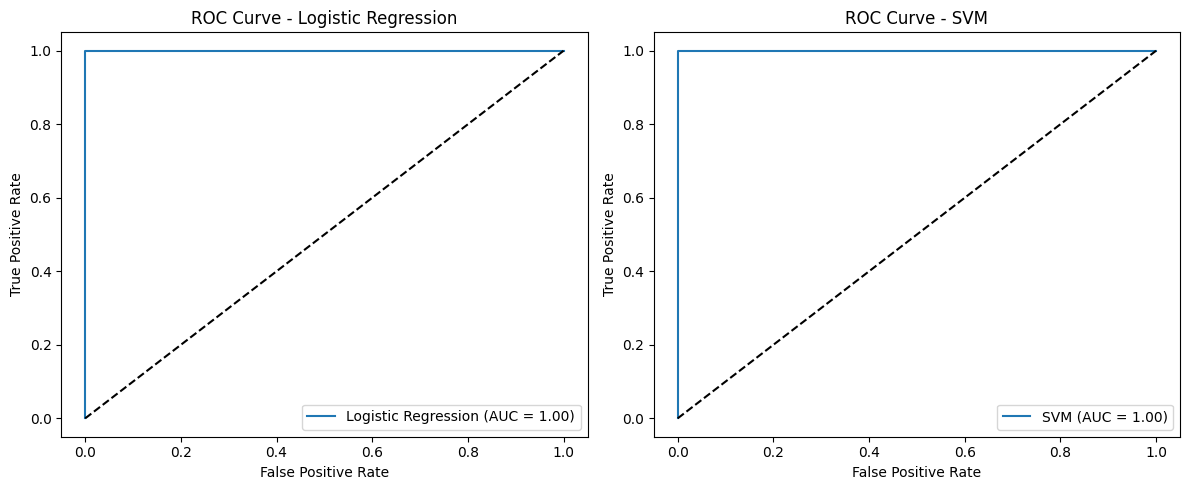

In [294]:
#Évaluation des modèles

#Accuracy
accuracy_logreg = accuracy_score(y_test, y_pred)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy of Logistic Regression: {accuracy_logreg:.2f}")
print(f"Accuracy of SVM: {accuracy_svm:.2f}")

#AUC
y_prob_logreg = logreg.predict_proba(X_test)[:, 1]
y_prob_svm = svm.decision_function(X_test)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)
auc_svm = roc_auc_score(y_test, y_prob_svm)
print(f"AUC of Logistic Regression: {auc_logreg:.2f}")
print(f"AUC of SVM: {auc_svm:.2f}")

#F1-Score
f1_logreg = f1_score(y_test, y_pred)
f1_svm = f1_score(y_test, y_pred_svm)
print(f"F1-Score of Logistic Regression: {f1_logreg:.2f}")
print(f"F1-Score of SVM: {f1_svm:.2f}")

#Matrice de confusion
conf_matrix_logreg = confusion_matrix(y_test, y_pred)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(conf_matrix_logreg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix - SVM')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
plt.tight_layout()
plt.show()

#Courbe ROC
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {auc_logreg:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve - Logistic Regression')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[1].plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - SVM')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout()
plt.show()  

<div style="text-align: center; font-weight: bold; font-size: 125%">Conclusion </div><br> 

Dans ce projet, nous nous sommes intéressés à la variété de Stiefel. L’étude des géodésiques, combinée à des techniques de réduction de dimension, nous a permis d’illustrer comment un problème posé sur une variété peut être ramené à un espace linéaire plus facile à manipuler.

Ce travail montre également qu’en apprentissage, il n’existe pas une démarche unique : il est souvent nécessaire d’explorer plusieurs méthodes, de comparer leurs performances et de retenir celle qui s’adapte le mieux au problème étudié.

Enfin, nous avons mis en évidence la propriété d’antisymétrie des vecteurs tangents sur la variété de Stiefel, ce qui constitue un élément théorique central pour comprendre la géométrie de cet espace.